In [1]:
import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
from plotnine import (
    aes,
    geom_hline,
    geom_line,
    geom_ribbon,
    ggplot,
    labs,
    scale_x_datetime,
    theme_minimal,
)
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_percentage_error, root_mean_squared_error
from sklearn.model_selection import TimeSeriesSplit
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.seasonal import seasonal_decompose

/Users/samuelkoh/projects/help-shus-forecasting/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
random_state = 42

# Load and preprocess data
df = pd.read_csv("acm_ts.csv")
df["timestamp"] = pd.to_datetime(df["Reporting Period"], format="%Y %b")
df.rename(columns={"Value": "value"}, inplace=True)

# Feature Engineering
df["month"] = df["timestamp"].dt.month
df["sin_month"] = np.sin(2 * np.pi * df["month"] / 12)
df["cos_month"] = np.cos(2 * np.pi * df["month"] / 12)

# Create lag features (1 to 12 months)
for lag in range(1, 13):
    df[f"lag_{lag}"] = df["value"].shift(lag)

df["monthly_avg"] = df.groupby(df["month"])["value"].transform("mean")

# Drop NaN rows created by lagging
df.dropna(inplace=True)

# Train-test split (80-20)
split_point = int(len(df) * 0.8)
train_data = df[:split_point]
test_data = df[split_point:]

# Define features and target
features = ["sin_month", "cos_month", "monthly_avg"] + [
    f"lag_{i}" for i in range(1, 13)
]
target = "value"


# Hyperparameter optimization with Optuna
def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 1000, step=100),
        "max_depth": trial.suggest_int("max_depth", 5, 30),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 10),
        "max_features": trial.suggest_categorical(
            "max_features", ["sqrt", "log2", None]
        ),
        "bootstrap": trial.suggest_categorical("bootstrap", [True, False]),
    }

    model = RandomForestRegressor(**params, random_state=random_state)
    tscv = TimeSeriesSplit(n_splits=3)
    errors = []

    for train_idx, val_idx in tscv.split(train_data):
        train_X = train_data.iloc[train_idx][features]
        train_y = train_data.iloc[train_idx][target]
        val_X = train_data.iloc[val_idx][features]
        val_y = train_data.iloc[val_idx][target]

        model.fit(train_X, train_y)
        predictions = model.predict(val_X)
        errors.append(root_mean_squared_error(val_y, predictions))

    return np.mean(errors)


study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=50)

# Train the best model
best_params = study.best_params
best_model = RandomForestRegressor(**best_params, random_state=random_state)
best_model.fit(train_data[features], train_data[target])

# Forecasting
forecast = best_model.predict(test_data[features])
test_data["Forecast"] = forecast

# Metrics Calculation
rmse_rf = root_mean_squared_error(test_data["value"], test_data["Forecast"])
mape_rf = mean_absolute_percentage_error(test_data["value"], test_data["Forecast"])

[I 2025-01-28 14:07:39,196] A new study created in memory with name: no-name-b8270da1-0dcb-4389-aaf6-2b2426c8b3b3
[I 2025-01-28 14:07:40,123] Trial 0 finished with value: 11.383432145591838 and parameters: {'n_estimators': 800, 'max_depth': 11, 'min_samples_split': 6, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 0 with value: 11.383432145591838.
[I 2025-01-28 14:07:40,480] Trial 1 finished with value: 11.015896773548237 and parameters: {'n_estimators': 300, 'max_depth': 16, 'min_samples_split': 9, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 1 with value: 11.015896773548237.
[I 2025-01-28 14:07:40,827] Trial 2 finished with value: 11.270136727355037 and parameters: {'n_estimators': 300, 'max_depth': 16, 'min_samples_split': 4, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 1 with value: 11.015896773548237.
[I 2025-01-28 14:07:41,877] Trial 3 finished with value: 11.404237250915694 

In [3]:
# Print Metrics
print(f"RMSE: {rmse_rf:.2f}")
print(f"MAPE: {mape_rf:.2%}")

RMSE: 6.78
MAPE: 16.57%


/Users/samuelkoh/projects/help-shus-forecasting/.venv/lib/python3.11/site-packages/mizani/breaks.py:448: FutureWarning: Passing the width as the parameter has been deprecated and will not work in a future version. Use breaks_date(width="4 years")


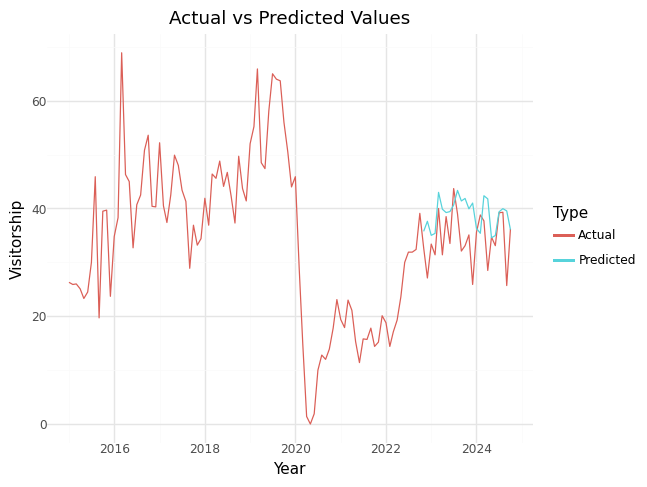

In [4]:
# Visualization 1: Actual vs Predicted
actual_vs_predicted_data = pd.concat(
    [
        pd.DataFrame(
            {
                "timestamp": train_data["timestamp"],
                "value": train_data["value"],
                "Type": "Actual",
            }
        ),
        pd.DataFrame(
            {
                "timestamp": test_data["timestamp"],
                "value": test_data["value"],
                "Type": "Actual",
            }
        ),
        pd.DataFrame(
            {
                "timestamp": test_data["timestamp"],
                "value": forecast,
                "Type": "Predicted",
            }
        ),
    ]
)
actual_vs_predicted_plot = (
    ggplot(actual_vs_predicted_data, aes(x="timestamp", y="value", color="Type"))
    + geom_line()
    + scale_x_datetime(date_breaks="2 years", date_labels="%Y")
    + labs(title="Actual vs Predicted Values", x="Year", y="Visitorship")
    + theme_minimal()
)
actual_vs_predicted_plot.draw()

/Users/samuelkoh/projects/help-shus-forecasting/.venv/lib/python3.11/site-packages/mizani/breaks.py:448: FutureWarning: Passing the width as the parameter has been deprecated and will not work in a future version. Use breaks_date(width="4 years")


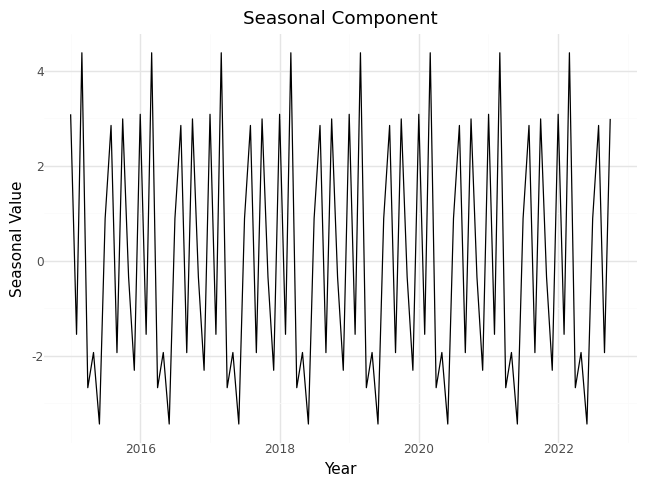

In [5]:
# Visualization 2: Seasonal Decomposition
result = seasonal_decompose(train_data["value"], period=12, model="additive")
seasonal_data = pd.DataFrame(
    {"timestamp": train_data["timestamp"], "Seasonal": result.seasonal}
)
seasonal_plot = (
    ggplot(seasonal_data, aes(x="timestamp", y="Seasonal"))
    + geom_line()
    + scale_x_datetime(date_breaks="2 years", date_labels="%Y")
    + labs(title="Seasonal Component", x="Year", y="Seasonal Value")
    + theme_minimal()
)
seasonal_plot.draw()

/var/folders/jx/y7nn61_n2_lg0hbhyl4sp1_m0000gn/T/ipykernel_56128/111526672.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
/var/folders/jx/y7nn61_n2_lg0hbhyl4sp1_m0000gn/T/ipykernel_56128/111526672.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
/Users/samuelkoh/projects/help-shus-forecasting/.venv/lib/python3.11/site-packages/mizani/breaks.py:448: FutureWarning: Passing the width as the parameter has been deprecated and will not work in a future version. Use breaks_date(width="4 years")


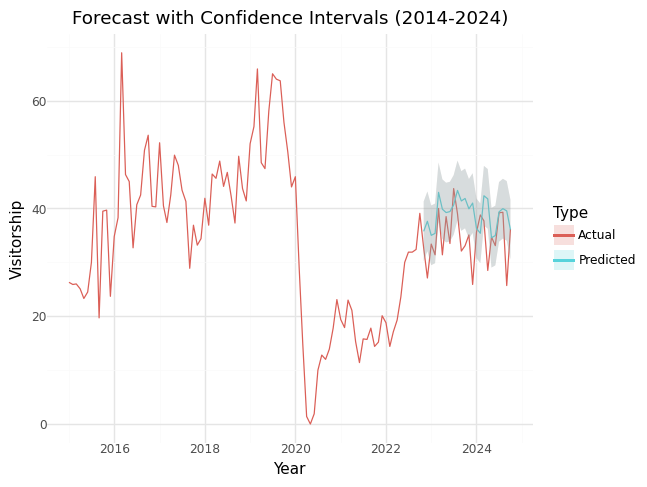

In [6]:
# Merge confidence intervals with forecast data
test_data.loc[:, "lower_ci"] = (
    test_data["Forecast"] - 1.96 * test_data["Forecast"].std()
)
test_data.loc[:, "upper_ci"] = (
    test_data["Forecast"] + 1.96 * test_data["Forecast"].std()
)

forecast_plot_data = pd.concat(
    [
        pd.DataFrame(
            {
                "timestamp": train_data["timestamp"],
                "value": train_data["value"],
                "Type": "Actual",
            }
        ),
        pd.DataFrame(
            {
                "timestamp": test_data["timestamp"],
                "value": test_data["value"],
                "Type": "Actual",
            }
        ),
        pd.DataFrame(
            {
                "timestamp": test_data["timestamp"],
                "value": test_data["Forecast"],
                "Type": "Predicted",
            }
        ),
    ]
).merge(test_data[["timestamp", "lower_ci", "upper_ci"]], on="timestamp", how="left")

# Corrected visualization without explicit upper/lower bound lines
confidence_plot = (
    ggplot(forecast_plot_data, aes(x="timestamp"))
    + geom_line(aes(y="value", color="Type"))
    + geom_ribbon(aes(ymin="lower_ci", ymax="upper_ci", fill="Type"), alpha=0.2)
    + scale_x_datetime(date_breaks="2 years", date_labels="%Y")
    + labs(
        title="Forecast with Confidence Intervals (2014-2024)",
        x="Year",
        y="Visitorship",
    )
    + theme_minimal()
)
confidence_plot.draw()

/Users/samuelkoh/projects/help-shus-forecasting/.venv/lib/python3.11/site-packages/mizani/breaks.py:448: FutureWarning: Passing the width as the parameter has been deprecated and will not work in a future version. Use breaks_date(width="4 years")


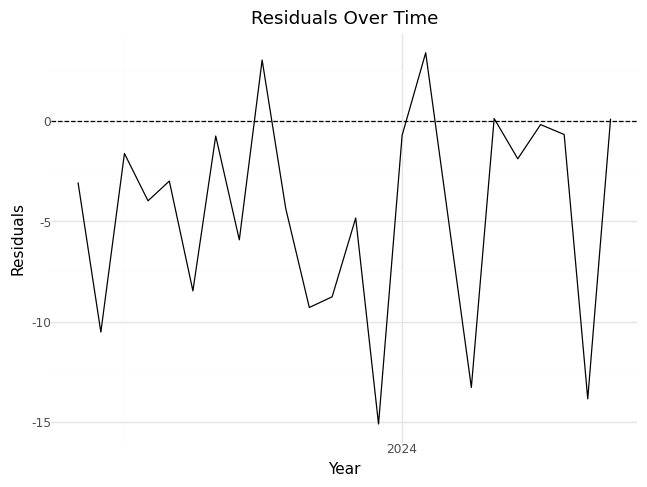

In [7]:
# Visualization 4: Residual Analysis
residuals = test_data["value"] - test_data["Forecast"]
residual_data = pd.DataFrame(
    {"timestamp": test_data["timestamp"], "Residuals": residuals}
)
residual_plot = (
    ggplot(residual_data, aes(x="timestamp", y="Residuals"))
    + geom_line()
    + geom_hline(yintercept=0, linetype="dashed")
    + scale_x_datetime(date_breaks="2 years", date_labels="%Y")
    + labs(title="Residuals Over Time", x="Year", y="Residuals")
    + theme_minimal()
)
residual_plot.draw()

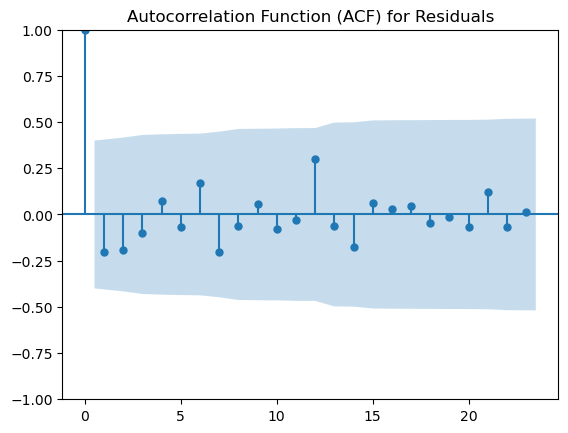

In [8]:
# Adjust lags for ACF to match the length of residuals
max_lags = min(len(residuals) - 1, 40)

# Autocorrelation Function (ACF) Test
acf_plot = plot_acf(residuals, lags=max_lags)
plt.title("Autocorrelation Function (ACF) for Residuals")
plt.show()

In [9]:
# Determine the maximum valid lag based on the residual length
max_lag = len(residuals) - 1

# Generate lags dynamically up to max_lag
valid_lags = [lag for lag in [10, 20, 30] if lag <= max_lag]

# Box-Ljung Test
if valid_lags:  # Only perform the test if there are valid lags
    ljungbox_results = acorr_ljungbox(residuals, lags=valid_lags, return_df=True)
    print("Box-Ljung Test Results:")
    print(ljungbox_results)
else:
    print("Box-Ljung Test skipped: residuals too short for specified lags.")

    # Hypothesis Testing Interpretation
for lag, p_value in zip(ljungbox_results.index, ljungbox_results["lb_pvalue"]):
    if p_value < 0.05:
        print(
            f"Lag {lag}: Reject the null hypothesis (p-value={p_value:.4f}). Residuals are not white noise."
        )
    else:
        print(
            f"Lag {lag}: Fail to reject the null hypothesis (p-value={p_value:.4f}). Residuals appear to be white noise."
        )

Box-Ljung Test Results:
      lb_stat  lb_pvalue
10   5.872044   0.825897
20  14.266083   0.816753
Lag 10: Fail to reject the null hypothesis (p-value=0.8259). Residuals appear to be white noise.
Lag 20: Fail to reject the null hypothesis (p-value=0.8168). Residuals appear to be white noise.
